In [161]:
import numpy as np
import matplotlib.pyplot as plt
from few.trajectory.inspiral import EMRIInspiral
from multispline.spline import CubicSpline
import os

# Some elliptic functions for evaluating geodesic frequencies
from few.utils.elliptic import EllipK, EllipE, EllipPi

# base classes
from few.trajectory.ode.base import ODEBase

from typing import Union, Optional

from few.utils.utility import get_fundamental_frequencies, get_separatrix, ELQ_to_pex

from few.waveform import FastSchwarzschildEccentricFluxBicubic

from scipy.special import lambertw

# Define the trajectories for the three parts of the IMR waveform

## Inspiral

In [162]:
# define trajectory RHS class
class SchwarzCirc1PA(ODEBase):
    """
    Schwarzschild circular flux ODE.
    Args:
        use_ELQ: If True, the ODE will output derivatives of the orbital elements of (E, L, Q). Defaults to False.
    """

    def __init__(self, *args, use_ELQ: bool = False, **kwargs):
        super().__init__(*args, use_ELQ=use_ELQ, **kwargs)

        data = np.loadtxt(os.getcwd() + "/data/QuasiCircularData_new.dat")
        
        x = np.unique(data[:, 0])

        self.pdot_interp_0pa =  CubicSpline(x, data[:, 1])
        self.pdot_interp_1pa =  CubicSpline(x, data[:, 2])

    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    @property
    def separatrix_buffer_dist(self):
        return 0.001

    @property
    def supports_ELQ(self):
        return False

    # @property
    # def flux_output_convention(self):
    #     return "pex"

    @property
    def inspiral_type(self):
        return 'inspiral'

    def distance_to_outer_boundary(self, y):
        p, e, x = self.get_pex(y)
        dist_p = 3.817 - np.log((p - 2. * e - 2.1))
        dist_e = 0.75 - e

        if dist_p < 0 or dist_e < 0:
            mult = -1
        else:
            mult = 1

        dist = mult * min(abs(dist_p), abs(dist_e))
        return dist

    def interpolate_flux_grids(
              self, p: float
              ) -> tuple[float]:

        if p < 6.25 or p > 30.: 
            raise ValueError("Interpolation: p out of bounds.")

        f0PA0PN = - 64./(5*(p**3))
        f1PA0PN = 176./(5*(p**4))

        pdot_0pa = (self.pdot_interp_0pa(p)/(p**4))+f0PA0PN
        if self.additional_args[0] != 1 and self.additional_args[0] != 0 :  #setting 1pa or 0pa
            raise ValueError("args for 1PA must be either 0 (for 0PA) or 1 (for 1PA)")
        pdot_1pa = self.additional_args[0]*(((self.pdot_interp_1pa(p))/(p**5))+f1PA0PN)
        return [pdot_0pa, pdot_1pa]

    def evaluate_rhs(self, y: Union[list[float], np.ndarray]) -> list[Union[float, np.ndarray]]:
        if self.use_ELQ:
            E, L, Q = y[:3]
            p, e, x = ELQ_to_pex(self.a, E, L, Q)

        else:
            p, e, x = y[:3]
            
        #eps=m2/m1
        eps = self.epsilon
        nu = eps/((1+eps)**2)
        Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(self.a, p, e, x)
        pdot_0pa, pdot_1pa = self.interpolate_flux_grids(p)
         
        pdot  = (nu/eps)*(pdot_0pa+(nu*pdot_1pa))
        return [pdot, 0., 0., Omega_phi, Omega_theta, Omega_r]

## Transition

In [163]:
from multispline.spline import CubicSpline

notebook_dir = os.getcwd()
parent_dir=os.path.dirname(notebook_dir)
sample_points0PLT,sample_values0PLT=np.transpose(np.loadtxt(os.path.join(parent_dir,"data_for_FEW/Schwarzschild0PLTdata.csv"),delimiter=","))
sample_points2PLT,sample_values2PLT=np.transpose(np.loadtxt(os.path.join(parent_dir,"data_for_FEW/Schwarzschild2PLTdata.csv"),delimiter=","))
Fdeltar0PLT = CubicSpline(sample_points0PLT, sample_values0PLT)
Fdeltar2PLT = CubicSpline(sample_points2PLT, sample_values2PLT)

In [164]:
class Schwarzschild_Transition(ODEBase):
    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    # @property
    # def flux_output_convention(self):
    #     return "pex"

    def cache_values_and_check_bounds(self,y):
        return True

    @property
    def inspiral_type(self):
        return 'transition'

    def Fr0PLT(self,r,nu):
        return (nu**(3./5.)*(-2.*r**(5./2.)/3.)*Fdeltar0PLT((1/r**(3./2.)-1/(6.**(3./2.)))/nu**(2./5.)))
    def Fr2PLT(self,r,nu):
        return (nu**(3./5.)*(-2.*r**(5./2.)/3.)*Fdeltar0PLT((1/r**(3./2.)-1/(6.**(3./2.)))/nu**(2./5.))+nu*(-2.*r**(5./2.)/3.)*Fdeltar2PLT((1/r**(3./2.)-1/(6.**(3./2.)))/nu**(2./5.)))
#    def Omega0PLT(self,p,nu):
#        return nu**(2./5.) * (-(p-6.)/nu**(2./5.))/(24.*np.sqrt(6))
#    def Omega2PLT(self,p,nu):
#        return nu**(2./5.) * (-(p-6.)/nu**(2./5.))/(24.*np.sqrt(6)) + nu**(4./5.) * (5.*(-(p-6.)/nu**(2./5.))**2.-2592.*Fdeltar0PLT((-(p-6.)/nu**(2./5.)))*Fdeltar0PLT.deriv(-(p-6.)/nu**(2./5.)))/(576.*np.sqrt(6.))

    def evaluate_rhs(self, y):
        # guard against bad integration steps
        p, e, xI = y[:3]

        eps = self.epsilon
        nu = eps/((1+eps)**2)
        
        # Azimuthal frequency
        Omega_phi = 1/p**(3./2.)

        # time derivatives
        pdot = 1/eps*self.Fr2PLT(p,nu)

        edot = 0.0

        xIdot = 0.0

        Phi_phi_dot = Omega_phi
        Phi_theta_dot = 0.
        Phi_r_dot = 0.

        dydt = [pdot, edot, xIdot, Phi_phi_dot, Phi_theta_dot, Phi_r_dot]

        return dydt

## Plunge

In [165]:
# this class defines the right-hand side of the ODE
# we define the method "evaluate_rhs" according to our derivatives
# we set the "equatorial" and "background" properties accordingly
# we also set the "flux_output_convention" property to "pex" to tell the trajectory module what
# the RHS derivatives correspond to
class Schwarzschild_Plunge(ODEBase):
    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    def cache_values_and_check_bounds(self,y):
        return True

    @property
    def inspiral_type(self):
        return 'plunge'

    # @property
    # def flux_output_convention(self):
    #     return "pex"

    def rs(self,r):
        return r + 2*np.log(r-2)
    
    def rOfrs(self,rs):
        return np.real(2*(1+lambertw(0.5*np.sqrt(np.exp(rs-2)))))
    
    def evaluate_rhs(self, y):
        # guard against bad integration steps
        ps, e, xI = y[:3]
        p = self.rOfrs(ps)

        eps = self.epsilon
        nu = eps/((1+eps)**2)
        
        #pdot = (-1/(2**(3./2.))*(6/p-1)**(3./2.)*(1-2/p))/(m2/m1)
        psdot = (-1/(2**(3./2.))*(6./p-1.)**(3./2.))/eps
        edot = 0
        xIdot = 0
        Phi_phi_dot = np.sqrt(3./2.)*3/p**2*(1-2/p)
        Phi_theta_dot = 0
        Phi_r_dot = 0

        dydt = [psdot, edot, xIdot, Phi_phi_dot, Phi_theta_dot, Phi_r_dot]

        return dydt

# Compute the trajectory

In [312]:
m1 = 1e4
m2 = 1e6
e0 = 0.0
x0 = 1.0

p0insp = 10
Tinsp = .02

In [313]:
insp1PA = EMRIInspiral(func=SchwarzCirc1PA)

traj1PA = insp1PA(m1, m2, 0.0, p0insp, e0, x0, T=Tinsp, dt=.05,upsample=True)

t1PA,p1PA,e1PA,x1PA,Phi_phi1PA,Phi_theta1PA,Phi_r1PA = traj1PA

In [314]:
# When using up sampling:
# For some reason the plunge is not stopping exactly at at the boundary.
# The code is also pads with zeroes when using upsampling. Is there a way to turn that off?

p1PA = np.trim_zeros(p1PA)
t1PA = t1PA[:len(p1PA)]
Phi_phi1PA = Phi_phi1PA[:len(p1PA)]

In [315]:
p0trans = p1PA[-1]
Ttrans = .04


trans = EMRIInspiral(func=Schwarzschild_Transition)

trajTrans = trans(m1, m2, 0.0, p0trans, e0, 1.0, T=Ttrans, dt=.05, upsample=True)

tTrans,pTrans,eTrans,xTrans,Phi_phiTrans,Phi_thetaTrans,Phi_rTrans = trajTrans

In [316]:
# When using up sampling:
# For some reason the transition is not stopping exactly at at the boundary.
# The code is also pads with zeroes when using upsampling. Is there a way to turn that off?

pTrans = np.trim_zeros(pTrans)
tTrans = tTrans[:len(pTrans)]
Phi_phiTrans = Phi_phiTrans[:len(pTrans)]

In [399]:
#For the plunge we solve for ps = rs(p)
def rstar(r):
    return r + 2*np.log(r-2)
def rOfrs(rs):
    return np.real(2*(1+lambertw(0.5*np.sqrt(np.exp(rs-2)))))
ps0plunge = rstar(pTrans[-1])
Tplunge = 0.0001

plunge = EMRIInspiral(func=Schwarzschild_Plunge)

trajPlunge = plunge(m1, m2, 0.0, ps0plunge, e0, x0, T=Tplunge, dt=.05,upsample=True)

tPlunge,psPlunge,ePlunge,xPlunge,Phi_phiPlunge,Phi_thetaPlunge,Phi_rPlunge = trajPlunge

In [400]:
# When using up sampling:
# For some reason the plunge is not stopping exactly at at the boundary.
# The code is also pads with zeroes when using upsampling. Is there a way to turn that off?

psPlunge = np.trim_zeros(psPlunge)
tPlunge = tPlunge[:len(psPlunge)]
Phi_phiPlunge = Phi_phiPlunge[:len(psPlunge)]

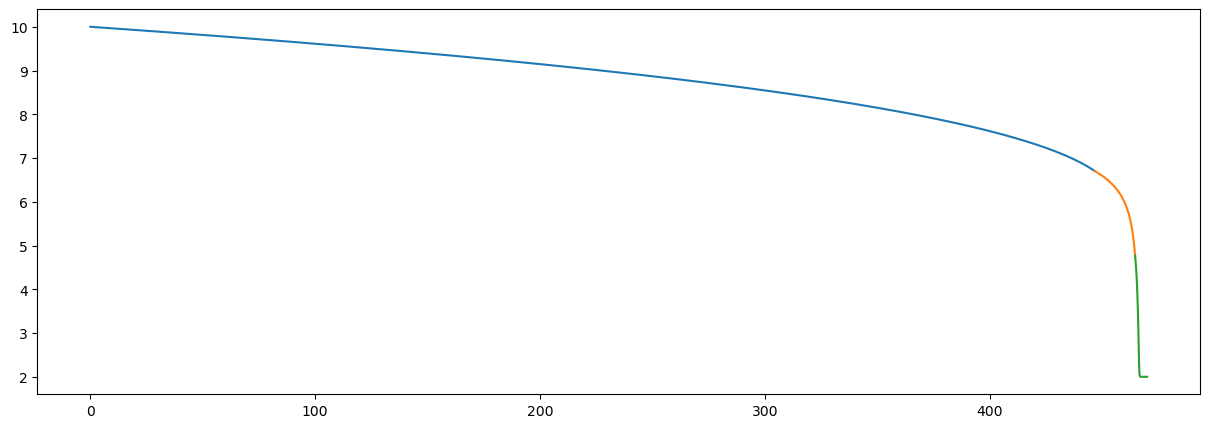

In [401]:
plt.plot(t1PA,p1PA)
plt.plot(tTrans+t1PA[-1],pTrans)
plt.plot(tPlunge+t1PA[-1]+tTrans[-1], rOfrs(psPlunge))

# Define the waveform generators

In [402]:
waveform1PA = FastSchwarzschildEccentricFluxBicubic(inspiral_kwargs={'func':SchwarzCirc1PA})

wav1PA = waveform1PA(m1,m2,p0insp,e0,0,0,dt=.05,T=Tinsp,mode_selection=[(2,2,0)])

In [403]:
t1PAwav = .05 * np.arange(0,len(wav1PA),1)

In [404]:
#plt.plot(t1PAwav,wav1PA.real)

In [405]:
def Amp2PLT(p,eps):
    ampdata = np.loadtxt(os.path.join(parent_dir,"data_for_FEW/SchwarzschildAmpdata.csv"),delimiter=",")
    return eps*((ampdata[0]+1j*ampdata[1])+(ampdata[2]+1j*ampdata[3])*(1/p**(3./2.)-1/(6.**(3./2.))))

In [406]:
WF2PLT=Amp2PLT(pTrans,(m2*m1)/(m1+m2)**2.)*np.exp(-2j*Phi_phiTrans)

In [407]:
#plt.plot(tTrans,WF2PLT.real)

In [408]:
dataPlungel2m2 = np.loadtxt(os.path.join(parent_dir,"data_for_FEW/plungeAmps-l2m2.csv"),delimiter=",")
ReAmpl2m2 = CubicSpline(dataPlungel2m2[:,0], dataPlungel2m2[:,1])
ImAmpl2m2 = CubicSpline(dataPlungel2m2[:,0], dataPlungel2m2[:,2])

In [409]:
wavPlunge = ((m1*m2)/(m1+m2)**2.)*(ReAmpl2m2(psPlunge) + 1j* ImAmpl2m2(psPlunge))*np.exp(-2j*Phi_phiPlunge)

In [410]:
#plt.plot(tPlunge,np.real(wavPlunge))
#plt.xlim(0,475)
#plt.ylim(-0.75,0.75)

In [411]:
plt.rcParams["figure.figsize"] = (15,5)

(-1.1, 1.1)

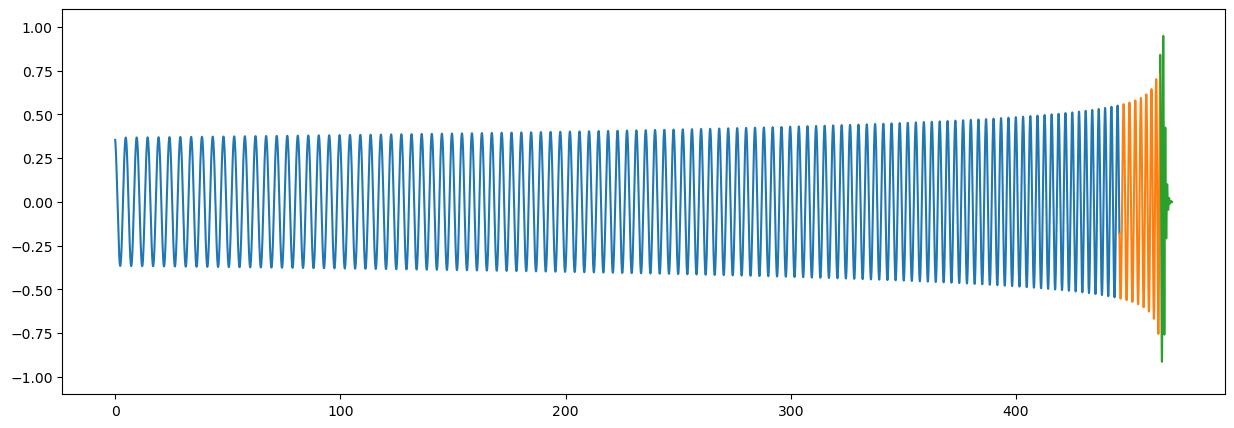

In [412]:
plt.plot(t1PAwav,wav1PA.real)
plt.plot(tTrans+t1PAwav[-1],(WF2PLT/WF2PLT[0]*wav1PA[-1]).real)
plt.plot(tPlunge+t1PAwav[-1]+tTrans[-1],np.real(wavPlunge/wavPlunge[0]*WF2PLT[-1]/WF2PLT[0]*wav1PA[-1]))
plt.ylim(-1.1,1.1)
#plt.savefig("/Users/niels/Downloads/FEW-IMR-q10-l2m2.pdf")